# Import

In [ ]:
import numpy as np

import sys
sys.path.append('../')
from src.utils.data_preprocessing import load_processed_data
from src.dim_reduction.ica import ICA_1D

# Variables

In [ ]:
SAMPLING_FREQUENCY = 100
TASK = "superdiagnostic"
CLASS_NAMES = ['MI', 'NORM']

DATA_DIR = "../data/raw/ptb_xl_ecg/"
PREPROCESSED_DIR = f"../data/preprocessed/"
SCALER_DIR = f"../data/results/scaler/"

date_today = '2025_08_29' #datetime.now().strftime("%Y_%m_%d")
MODEL_PATH = f"../src/models/trained/vgg16_1d_trained_{date_today}.pth"
HISTORY_PATH = f"../data/results/training_history/training_history_{date_today}.csv"
CHECKPOINT_PATH = f'../src/models/checkpoints/checkpoint_{date_today}.pth'

# Load Data

In [3]:
X_train, y_train = load_processed_data(PREPROCESSED_DIR, "train", class_names=CLASS_NAMES)
X_val, y_val = load_processed_data(PREPROCESSED_DIR, "val", class_names=CLASS_NAMES)
X_test, y_test = load_processed_data(PREPROCESSED_DIR, "test", class_names=CLASS_NAMES)

Loading processed data from ../data/preprocessed/ with prefix train
Loading processed data from ../data/preprocessed/ with prefix val
Loading processed data from ../data/preprocessed/ with prefix test


In [4]:
splits = {'Train': y_train, 'Validation': y_val, 'Test': y_test}

for split_name, y_split in splits.items():
    y_arr = np.asarray(y_split)
    # Multi-Label: Summiere pro Klasse (Spalte)
    if y_arr.ndim == 2 and y_arr.shape[1] == len(CLASS_NAMES):
        counts = y_arr.sum(axis=0)
    else:
        counts = np.bincount(y_arr, minlength=len(CLASS_NAMES))
    perc = counts / counts.sum() * 100
    print(f"{split_name}:")
    for name, c, p in zip(CLASS_NAMES, counts, perc):
        print(f"  {name}: {int(c)} ({p:.2f}%)")
    print(f"  TOTAL: {int(counts.sum())} (100.00%)\n")

Train:
  MI: 4379 (25.63%)
  NORM: 7595 (44.46%)
  OTHER: 5110 (29.91%)
  TOTAL: 17084 (100.00%)

Validation:
  MI: 540 (25.16%)
  NORM: 955 (44.50%)
  OTHER: 651 (30.34%)
  TOTAL: 2146 (100.00%)

Test:
  MI: 550 (25.49%)
  NORM: 963 (44.62%)
  OTHER: 645 (29.89%)
  TOTAL: 2158 (100.00%)



# ICA

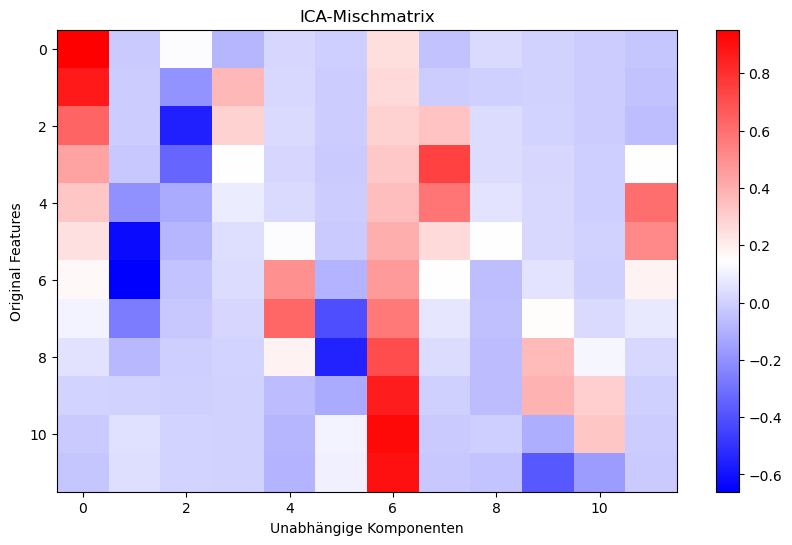

In [5]:
n_components = 12
ica_leads = ICA_1D(n_components=n_components, standardize=False, feature_mode='leads')

ica_leads.fit(X_train)
X_train_ica = ica_leads.transform(X_train)
X_val_ica = ica_leads.transform(X_val)
X_test_ica = ica_leads.transform(X_test)

In [ ]:
ica_leads.plot_mixing_matrix(figsize=(10, 6))

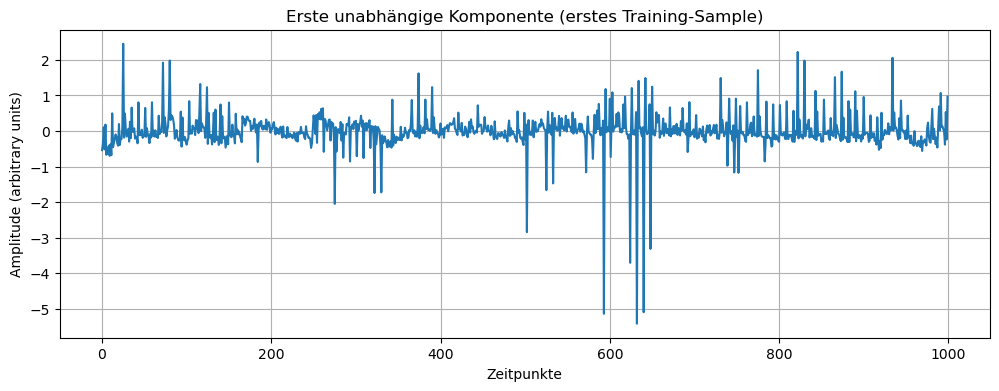

In [6]:
# Optional: Ein Beispiel, wie du die erste unabhängige Komponente visualisieren könntest
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(X_train_ica[0, :, 0])  # Beispiel: erste Komponente, erstes Sample
plt.title("Erste unabhängige Komponente (erstes Training-Sample)")
plt.xlabel("Zeitpunkte")
plt.ylabel("Amplitude (arbitrary units)")
plt.grid(True)
plt.show()